# RAG Workshop #2 


## データを準備


### ChromaDB というVector DBを使用してデータをEmbedding

In [8]:
import operator
import uuid
from typing import Annotated, TypedDict

from langchain.retrievers import ParentDocumentRetriever
from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain.storage import InMemoryStore
from langchain_chroma import Chroma
from langchain_community.document_loaders import AsyncHtmlLoader
from langchain_community.document_transformers import Html2TextTransformer
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from langchain_ollama import ChatOllama
from langchain_text_splitters import HTMLSectionSplitter, RecursiveCharacterTextSplitter
from langgraph.graph import END, START, StateGraph

import utils

In [9]:
embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
html2text_transformer = Html2TextTransformer()


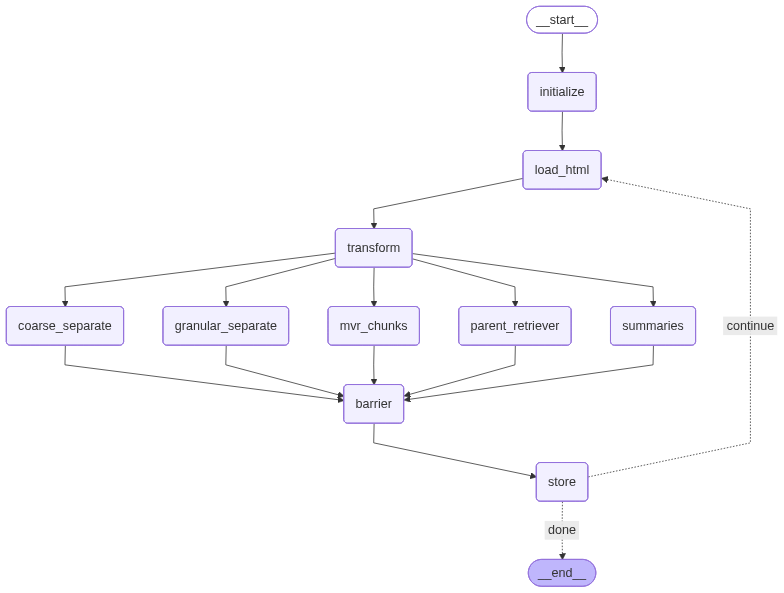

### State

In [10]:
class InputState(TypedDict):
    """Input state - only what the user needs to provide"""

    urls: list[str]


class RAGPipelineState(TypedDict):
    """Complete internal state for the RAG processing pipeline"""

    # Input (from InputState) - immutable after initialization
    urls: list[str]
    current_url_index: int

    # Raw data - written by single nodes (overwritten each URL)
    raw_html_docs: list[Document]
    text_docs: list[Document]

    # Chunks for this URL only - overwritten each iteration (no accumulation)
    coarse_chunks_separate: list[Document]
    granular_chunks_separate: list[Document]

    # For ParentDocumentRetriever approach
    parent_retriever_docs: list[Document]

    # For MultiVectorRetriever with granular->coarse (no accumulation)
    mvr_coarse_chunks: list[Document]
    mvr_coarse_chunk_ids: list[str]
    mvr_granular_chunks: list[Document]

    # For MultiVectorRetriever with summaries (no accumulation)
    summary_coarse_chunks: list[Document]
    summary_chunk_ids: list[str]
    summaries: list[Document]

    # Collections and retrievers - set once during initialization
    granular_collection: Chroma
    coarse_collection: Chroma
    parent_doc_retriever: ParentDocumentRetriever
    multi_vector_retriever_granular: MultiVectorRetriever
    multi_vector_retriever_summaries: MultiVectorRetriever

    # Error handling - last write wins
    error: str


class OutputState(TypedDict):
    """Output state - only what gets returned to the user"""

    urls_processed: int
    granular_collection: Chroma
    coarse_collection: Chroma
    parent_doc_retriever: ParentDocumentRetriever
    multi_vector_retriever_granular: MultiVectorRetriever
    multi_vector_retriever_summaries: MultiVectorRetriever
    error: str

### Initialization

In [11]:
def initialize_collections(state: RAGPipelineState) -> dict:
    """Initialize all vector stores and retrievers"""
    print("Initializing collections and retrievers...")

    # 1. Separate collections for coarse and granular
    granular_collection = Chroma(
        collection_name="tokyo_granular", embedding_function=embedding_model
    )
    granular_collection.reset_collection()

    coarse_collection = Chroma(
        collection_name="tokyo_coarse", embedding_function=embedding_model
    )
    coarse_collection.reset_collection()

    # 2. ParentDocumentRetriever (child chunks -> parent chunks)
    child_chunks_collection = Chroma(
        collection_name="tokyo_child_chunks", embedding_function=embedding_model
    )
    child_chunks_collection.reset_collection()

    parent_doc_store = InMemoryStore()
    parent_splitter = RecursiveCharacterTextSplitter(chunk_size=3000)
    child_splitter = RecursiveCharacterTextSplitter(chunk_size=500)

    parent_doc_retriever = ParentDocumentRetriever(
        vectorstore=child_chunks_collection,
        docstore=parent_doc_store,
        child_splitter=child_splitter,
        parent_splitter=parent_splitter,
    )

    # 3. MultiVectorRetriever for granular->coarse mapping
    mvr_granular_collection = Chroma(
        collection_name="tokyo_mvr_granular", embedding_function=embedding_model
    )
    mvr_granular_collection.reset_collection()

    mvr_granular_docstore = InMemoryStore()

    multi_vector_retriever_granular = MultiVectorRetriever(
        vectorstore=mvr_granular_collection,
        docstore=mvr_granular_docstore,
        id_key="doc_id",
    )

    # 4. MultiVectorRetriever for summaries->coarse mapping
    summaries_collection = Chroma(
        collection_name="tokyo_summaries", embedding_function=embedding_model
    )
    summaries_collection.reset_collection()

    summaries_docstore = InMemoryStore()

    multi_vector_retriever_summaries = MultiVectorRetriever(
        vectorstore=summaries_collection, docstore=summaries_docstore, id_key="doc_id"
    )

    return {
        "granular_collection": granular_collection,
        "coarse_collection": coarse_collection,
        "parent_doc_retriever": parent_doc_retriever,
        "multi_vector_retriever_granular": multi_vector_retriever_granular,
        "multi_vector_retriever_summaries": multi_vector_retriever_summaries,
        "current_url_index": 0,
        "error": None,
    }

### Functions

In [ ]:
# def load_html(state: RAGPipelineState) -> dict:
#     """Load HTML from current URL"""
#     try:
#         current_url = state["urls"][state["current_url_index"]]
#         print(
#             f"\nProcessing URL {state['current_url_index'] + 1}/{len(state['urls'])}: {current_url}"
#         )

#         html_loader = AsyncHtmlLoader(current_url)
#         raw_html_docs = html_loader.load()

#         return {"raw_html_docs": raw_html_docs, "error": None}
#     except Exception as e:
#         return {"error": f"HTML loading failed: {str(e)}"}


# class TransformToText:
#     def __init__(self):
#         self.html2text_transformer = Html2TextTransformer()

#     def transform_to_text(self, state):
#         """Transform HTML to text"""
#         try:
#             text_docs = html2text_transformer.transform_documents(
#                 state["raw_html_docs"]
#             )

#             return {"text_docs": text_docs, "error": None}
#         except Exception as e:
#             return {"error": f"HTML transformation failed: {str(e)}"}


# def transform_to_text(state: RAGPipelineState) -> dict:
#     """Transform HTML to text"""
#     try:
#         text_docs = html2text_transformer.transform_documents(state["raw_html_docs"])

#         return {"text_docs": text_docs, "error": None}
#     except Exception as e:
#         return {"error": f"HTML transformation failed: {str(e)}"}


# def create_separate_coarse_chunks(state: RAGPipelineState) -> dict:
#     """Create coarse chunks for separate collection approach"""
#     try:
#         text_splitter = RecursiveCharacterTextSplitter(
#             chunk_size=3000, chunk_overlap=300
#         )
#         coarse_chunks = text_splitter.split_documents(state["text_docs"])

#         return {
#             "coarse_chunks_separate": coarse_chunks,
#         }
#     except Exception as e:
#         return {"error": f"Separate coarse chunking failed: {str(e)}"}


# def create_separate_granular_chunks(state: RAGPipelineState) -> dict:
#     """Create granular chunks using HTML section splitter"""
#     try:
#         headers_to_split_on = [("h1", "Header 1"), ("h2", "Header 2")]
#         html_section_splitter = HTMLSectionSplitter(
#             headers_to_split_on=headers_to_split_on
#         )

#         all_chunks = []
#         for doc in state["raw_html_docs"]:
#             html_string = doc.page_content
#             temp_chunks = html_section_splitter.split_text(html_string)
#             all_chunks.extend(temp_chunks)

#         return {
#             "granular_chunks_separate": all_chunks,
#         }
#     except Exception as e:
#         return {"error": f"Separate granular chunking failed: {str(e)}"}


# def add_to_parent_retriever(state: RAGPipelineState) -> dict:
#     """Add documents to ParentDocumentRetriever"""
#     try:
#         state["parent_doc_retriever"].add_documents(state["text_docs"], ids=None)

#         return {}  # No state updates needed
#     except Exception as e:
#         return {"error": f"ParentDocumentRetriever failed: {str(e)}"}


# def create_mvr_chunks(state: RAGPipelineState) -> dict:
#     """Create coarse and granular chunks for MultiVectorRetriever (granular approach)"""
#     try:
#         parent_splitter = RecursiveCharacterTextSplitter(chunk_size=3000)
#         child_splitter = RecursiveCharacterTextSplitter(chunk_size=500)

#         coarse_chunks = parent_splitter.split_documents(state["text_docs"])
#         coarse_chunks_ids = [str(uuid.uuid4()) for _ in coarse_chunks]

#         all_granular_chunks = []
#         for i, coarse_chunk in enumerate(coarse_chunks):
#             coarse_chunk_id = coarse_chunks_ids[i]

#             granular_chunks = child_splitter.split_documents([coarse_chunk])

#             for granular_chunk in granular_chunks:
#                 granular_chunk.metadata["doc_id"] = coarse_chunk_id

#             all_granular_chunks.extend(granular_chunks)

#         return {
#             "mvr_coarse_chunks": coarse_chunks,
#             "mvr_coarse_chunk_ids": coarse_chunks_ids,
#             "mvr_granular_chunks": all_granular_chunks,
#         }
#     except Exception as e:
#         return {"error": f"MVR chunking failed: {str(e)}"}


# def generate_summaries(state: RAGPipelineState) -> dict:
#     """Generate summaries for MultiVectorRetriever (summary approach)"""
#     try:
#         parent_splitter = RecursiveCharacterTextSplitter(chunk_size=3000)
#         coarse_chunks = parent_splitter.split_documents(state["text_docs"])

#         llm = ChatOllama(model="gemma2:2b", temperature=0)
#         summarization_chain = (
#             {"document": lambda x: x.page_content}
#             | ChatPromptTemplate.from_template(
#                 "Summarize the following document concisely in 2-3 sentences:\n\n{document}"
#             )
#             | llm
#             | StrOutputParser()
#         )

#         coarse_chunks_ids = [str(uuid.uuid4()) for _ in coarse_chunks]
#         all_summaries = []

#         for i, coarse_chunk in enumerate(coarse_chunks):
#             coarse_chunk_id = coarse_chunks_ids[i]

#             summary_text = summarization_chain.invoke(coarse_chunk)
#             summary_doc = Document(
#                 page_content=summary_text,
#                 metadata={**coarse_chunk.metadata, "doc_id": coarse_chunk_id},
#             )

#             all_summaries.append(summary_doc)

#         return {
#             "summary_coarse_chunks": coarse_chunks,
#             "summary_chunk_ids": coarse_chunks_ids,
#             "summaries": all_summaries,
#         }
#     except Exception as e:
#         return {"error": f"Summary generation failed: {str(e)}"}


# def barrier_before_store(state: RAGPipelineState) -> dict:
#     """Barrier node to ensure all parallel branches complete before storing"""
#     print(
#         f"  → All parallel processing complete for URL {state['current_url_index'] + 1}"
#     )
#     return {}


# def store_all_embeddings(state: RAGPipelineState) -> dict:
#     """Store all embeddings in their respective collections"""
#     try:
#         print(f"  → Storing embeddings for URL {state['current_url_index'] + 1}")

#         # 1. Store in separate collections
#         if state.get("coarse_chunks_separate"):
#             state["coarse_collection"].add_documents(state["coarse_chunks_separate"])
#             print(f"    ✓ Stored {len(state['coarse_chunks_separate'])} coarse chunks")

#         if state.get("granular_chunks_separate"):
#             state["granular_collection"].add_documents(
#                 state["granular_chunks_separate"]
#             )
#             print(
#                 f"    ✓ Stored {len(state['granular_chunks_separate'])} granular chunks"
#             )

#         # 2. MultiVectorRetriever with granular chunks
#         if state.get("mvr_granular_chunks") and state.get("mvr_coarse_chunks"):
#             state["multi_vector_retriever_granular"].vectorstore.add_documents(
#                 state["mvr_granular_chunks"]
#             )
#             state["multi_vector_retriever_granular"].docstore.mset(
#                 list(zip(state["mvr_coarse_chunk_ids"], state["mvr_coarse_chunks"]))
#             )
#             print(
#                 f"    ✓ Stored {len(state['mvr_granular_chunks'])} MVR granular chunks"
#             )

#         # 3. MultiVectorRetriever with summaries
#         if state.get("summaries") and state.get("summary_coarse_chunks"):
#             state["multi_vector_retriever_summaries"].vectorstore.add_documents(
#                 state["summaries"]
#             )
#             state["multi_vector_retriever_summaries"].docstore.mset(
#                 list(zip(state["summary_chunk_ids"], state["summary_coarse_chunks"]))
#             )
#             print(f"    ✓ Stored {len(state['summaries'])} summaries")

#         # Increment the URL index
#         new_index = state["current_url_index"] + 1
#         print(f"  → Incrementing index: {state['current_url_index']} → {new_index}")

#         return {
#             "current_url_index": new_index,
#             "urls_processed": new_index,
#             "error": None,
#         }
#     except Exception as e:
#         print(f"  ✗ Storage error: {str(e)}")
#         return {"error": f"Storage failed: {str(e)}"}


# def check_more_urls(state: RAGPipelineState) -> str:
#     """Check if there are more URLs to process"""
#     if state.get("error"):
#         print(f"  ✗ Error detected: {state['error']}")
#         return "error"

#     current_index = state["current_url_index"]
#     total_urls = len(state["urls"])

#     print(f"\n→ Checking progress: URL {current_index}/{total_urls}")

#     if current_index < total_urls:
#         print(f"  → Continuing to next URL\n")
#         return "continue"

#     print(f"  ✓ All URLs processed!\n")
#     return "done"

### Pipeline Function

In [ ]:
html2text_transformer = Html2TextTransformer()

t = utils.TransformToText()


def create_rag_pipeline():
    """Create the complete RAG pipeline workflow"""

    # Use StateGraph with input/output schema (updated API)
    workflow = StateGraph(
        RAGPipelineState, input_schema=InputState, output_schema=OutputState
    )

    # Add nodes
    workflow.add_node("initialize", initialize_collections)
    workflow.add_node("load_html", utils.load_html)
    workflow.add_node("transform", t.transform_to_text)
    workflow.add_node("coarse_separate", utils.create_separate_coarse_chunks)
    workflow.add_node("granular_separate", utils.create_separate_granular_chunks)
    workflow.add_node("parent_retriever", utils.add_to_parent_retriever)
    workflow.add_node("mvr_chunks", utils.create_mvr_chunks)
    workflow.add_node("summaries", utils.generate_summaries)
    workflow.add_node("barrier", utils.barrier_before_store)  # Barrier node
    workflow.add_node("store", utils.store_all_embeddings)

    # Define flow
    workflow.add_edge(START, "initialize")
    workflow.add_edge("initialize", "load_html")
    workflow.add_edge("load_html", "transform")

    # All parallel processing branches from transform
    workflow.add_edge("transform", "coarse_separate")
    workflow.add_edge("transform", "granular_separate")
    workflow.add_edge("transform", "parent_retriever")
    workflow.add_edge("transform", "mvr_chunks")
    workflow.add_edge("transform", "summaries")

    # All converge at barrier, then barrier goes to store
    workflow.add_edge("coarse_separate", "barrier")
    workflow.add_edge("granular_separate", "barrier")
    workflow.add_edge("parent_retriever", "barrier")
    workflow.add_edge("mvr_chunks", "barrier")
    workflow.add_edge("summaries", "barrier")

    workflow.add_edge("barrier", "store")

    # Loop or end
    workflow.add_conditional_edges(
        "store",
        utils.check_more_urls,
        {"continue": "load_html", "done": END, "error": END},
    )

    return workflow.compile()

In [15]:
# Tokyo destination URLs
tokyo_cities = [
    "Tokyo",
    "Tokyo/Chiyoda",
    "Tokyo/Chuo",
    "Tokyo/Minato",
    "Tokyo/Shinjuku",
    "Tokyo/Shibuya",
    "Tokyo/Shinagawa",
    "Tokyo/Toshima",
    "Tokyo/Meguro",
    "Tokyo/Sumida",
    "Tokyo/Taio",
    "Tokyo/Bunkyo",
    "Tokyo/East",
    "Tokyo/North",
    "Tokyo/Nakano",
    "Tokyo/Ota",
    "Tokyo/Setagaya",
    "Tokyo/Suginami",
]
wikipedia_root_url = "https://en.wikivoyage.org/wiki"
tokyo_urls = [f"{wikipedia_root_url}/{d}" for d in tokyo_cities]

## Run App

In [16]:
app = create_rag_pipeline()
initial_state: InputState = {
    "urls": tokyo_urls,
}

result = app.invoke(initial_state, {"recursion_limit": 150})

Initializing collections and retrievers...

Processing URL 1/18: https://en.wikivoyage.org/wiki/Tokyo


Fetching pages: 100%|##########| 1/1 [00:05<00:00,  5.93s/it]


  → All parallel processing complete for URL 1
  → Storing embeddings for URL 1
    ✓ Stored 41 coarse chunks
    ✓ Stored 22 granular chunks
    ✓ Stored 357 MVR granular chunks
  → Incrementing index: 0 → 1

→ Checking progress: URL 1/18
  → Continuing to next URL


Processing URL 2/18: https://en.wikivoyage.org/wiki/Tokyo/Chiyoda


Fetching pages: 100%|##########| 1/1 [00:04<00:00,  4.96s/it]


  → All parallel processing complete for URL 2
  → Storing embeddings for URL 2
    ✓ Stored 11 coarse chunks
    ✓ Stored 14 granular chunks
    ✓ Stored 102 MVR granular chunks
  → Incrementing index: 1 → 2

→ Checking progress: URL 2/18
  → Continuing to next URL


Processing URL 3/18: https://en.wikivoyage.org/wiki/Tokyo/Chuo


...

  → All parallel processing complete for URL 16
  → Storing embeddings for URL 16
    ✓ Stored 7 coarse chunks
    ✓ Stored 15 granular chunks
    ✓ Stored 49 MVR granular chunks
  → Incrementing index: 15 → 16

→ Checking progress: URL 16/18
  → Continuing to next URL


Processing URL 17/18: https://en.wikivoyage.org/wiki/Tokyo/Setagaya


Fetching pages: 100%|##########| 1/1 [00:03<00:00,  3.11s/it]


  → All parallel processing complete for URL 17
  → Storing embeddings for URL 17
    ✓ Stored 9 coarse chunks
    ✓ Stored 15 granular chunks
    ✓ Stored 65 MVR granular chunks
  → Incrementing index: 16 → 17

→ Checking progress: URL 17/18
  → Continuing to next URL


Processing URL 18/18: https://en.wikivoyage.org/wiki/Tokyo/Suginami


Fetching pages: 100%|##########| 1/1 [00:01<00:00,  1.57s/it]


  → All parallel processing complete for URL 18
  → Storing embeddings for URL 18
    ✓ Stored 5 coarse chunks
    ✓ Stored 15 granular chunks
    ✓ Stored 36 MVR granular chunks
  → Incrementing index: 17 → 18

→ Checking progress: URL 18/18
  ✓ All URLs processed!



In [17]:
print(f"\nProcessed {result['urls_processed']} URLs")
query = "Tower Records"


Processed 18 URLs


In [18]:
print("\n1. Granular Collection (HTML sections):")
granular_results = result["granular_collection"].similarity_search(query, k=1)
if granular_results:
    print(f"   {granular_results[0].page_content[:150]}...")



1. Granular Collection (HTML sections):
   Connect 
 [ edit ] 
 
   Shinagawa Prince Executive Tower's North and South Annex .   2nd floor wireless hot-spot. Must purchase a ¥500 card at the fr...


In [19]:
print("\n2. Coarse Collection (3000 char chunks):")
coarse_results = result["coarse_collection"].similarity_search(query, k=1)
if coarse_results:
    print(f"   {coarse_results[0].page_content[:150]}...")

print("\n3. ParentDocumentRetriever (500 char child -> 3000 char parent):")
parent_results = result["parent_doc_retriever"].invoke(query)
if parent_results:
    print(f"   Retrieved {len(parent_results)} parent documents")
    print(f"   {parent_results[0].page_content[:150]}...")

print("\n4. MultiVectorRetriever - Granular (500 char granular -> 3000 char coarse):")
mvr_granular_results = result["multi_vector_retriever_granular"].invoke(query)
if mvr_granular_results:
    print(f"   Retrieved {len(mvr_granular_results)} documents")
    print(f"   {mvr_granular_results[0].page_content[:150]}...")

print("\n5. MultiVectorRetriever - Summaries (LLM summary -> 3000 char coarse):")
mvr_summary_results = result["multi_vector_retriever_summaries"].invoke(query)
if mvr_summary_results:
    print(f"   Retrieved {len(mvr_summary_results)} documents")
    print(f"   {mvr_summary_results[0].page_content[:150]}...")

print("\n" + "=" * 70)


2. Coarse Collection (3000 char chunks):
   ### Music

[edit]

  * Disk Union, Shinjuku 3-34-1 (Main Branch is near Shinjuku Sanchome Station), ☏ +81 3-3352-2697. You can get music, movies, and ...

3. ParentDocumentRetriever (500 char child -> 3000 char parent):
   Retrieved 4 parent documents
   ### Music

[edit]

  * Disk Union, Shinjuku 3-34-1 (Main Branch is near Shinjuku Sanchome Station), ☏ +81 3-3352-2697. You can get music, movies, and ...

4. MultiVectorRetriever - Granular (500 char granular -> 3000 char coarse):
   Retrieved 4 documents
   ### Music

[edit]

  * Disk Union, Shinjuku 3-34-1 (Main Branch is near Shinjuku Sanchome Station), ☏ +81 3-3352-2697. You can get music, movies, and ...

5. MultiVectorRetriever - Summaries (LLM summary -> 3000 char coarse):



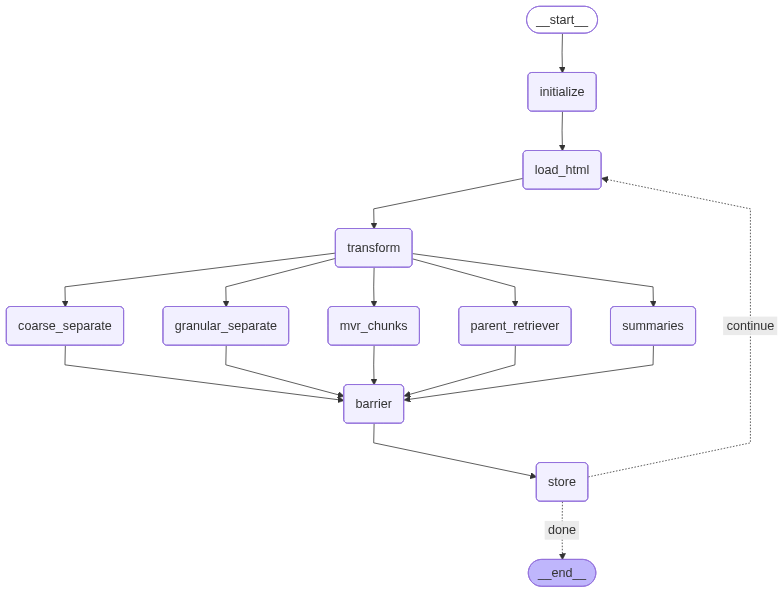

In [20]:
from IPython.display import Image


Image(app.get_graph().draw_mermaid_png())

In [ ]:
# Initialize collections
coarse_collection = Chroma(
    collection_name="tokyo_coarse_lg", embedding_function=embedding_model
)
coarse_collection.reset_collection()

granular_collection = Chroma(
    collection_name="tokyo_granular_lg", embedding_function=embedding_model
)
granular_collection.reset_collection()

summaries_collection = Chroma(
    collection_name="tokyo_summaries_lg", embedding_function=embedding_model
)
summaries_collection.reset_collection()

# MultiVectorRetriever setup
doc_store = InMemoryStore()
doc_key = "doc_id"

multi_vector_retriever = MultiVectorRetriever(
    vectorstore=granular_collection,
    docstore=doc_store,
    id_key=doc_key,
)

summary_retriever = MultiVectorRetriever(
    vectorstore=summaries_collection,
    docstore=InMemoryStore(),
    id_key=doc_key,
)

# Text transformers
html2text_transformer = Html2TextTransformer()
coarse_splitter = RecursiveCharacterTextSplitter(chunk_size=3000, chunk_overlap=300)
granular_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
headers_to_split_on = [("h1", "Header 1"), ("h2", "Header 2")]
html_section_splitter = HTMLSectionSplitter(headers_to_split_on=headers_to_split_on)

# LLM for summarization
llm = ChatOllama(model="gemma2:2b", temperature=0)
summarization_chain = (
    {"document": lambda x: x.page_content}
    | ChatPromptTemplate.from_template(
        "Summarize the following document in 2-3 concise sentences:\n\n{document}"
    )
    | llm
    | StrOutputParser()
)


In [ ]:
embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
chroma_client = chromadb.PersistentClient(path="./my_chroma_db")

vector_db = Chroma(
    client=chroma_client,
    collection_name="tourist_info",
    embedding_function=HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2"),
)

## LangGraph用のStateを用意

In [ ]:
class DocState(TypedDict):
    coarse_chunks: Annotated[list[Document], operator.add]
    granular_chunks: Annotated[list[Document], operator.add]

## Wikivoyage の Tokyo　URL を整理

In [ ]:
tokyo_cities = [
    "Tokyo",
    "Tokyo/Chiyoda",
    "Tokyo/Chuo",
    "Tokyo/Minato",
    "Tokyo/Shinjuku",
    "Tokyo/Shibuya",
    "Tokyo/Shinagawa",
    "Tokyo/Toshima",
    "Tokyo/Meguro",
    "Tokyo/Sumida",
    "Tokyo/Taio",
    "Tokyo/Bunkyo",
    "Tokyo/East",
    "Tokyo/North",
    "Tokyo/Nakano",
    "Tokyo/Ota",
    "Tokyo/Setagaya",
    "Tokyo/Suginami",
]

wikipedia_root_url = "https://en.wikivoyage.org/wiki"
tokyo_destination_urls = [f"{wikipedia_root_url}/{d}" for d in tokyo_cities]

## Vector DB を2つ定義
- `tokyo_granular_collection` : 細かいChunk
- `tokyo_coarse_collection` : 粗いChunk

In [ ]:
tokyo_granular_collection = Chroma(
    collection_name="tokyo_granular", embedding_function=embedding_model
)

tokyo_granular_collection.reset_collection()


tokyo_coarse_collection = Chroma(
    collection_name="tokyo_coarse", embedding_function=embedding_model
)

tokyo_coarse_collection.reset_collection()

## WikivoyageのURLを準備
- Tokyo各所のHTMLを粗い(coarse)なChunkと細かい(granular)なChunkに分け、Vector DB に保存

### `coarse` なChunkの作成と `granular` なChunkをそれぞれ保存するための関数を準備

In [ ]:
html2text_transformer = Html2TextTransformer()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=3000, chunk_overlap=300)


def split_docs_into_coarse_chunks(docs):
    text_docs = html2text_transformer.transform_documents(docs)
    coarse_chunks = text_splitter.split_documents(text_docs)

    return coarse_chunks


headers_to_split_on = [("h1", "Header 1"), ("h2", "Header 2")]
html_section_splitter = HTMLSectionSplitter(headers_to_split_on=headers_to_split_on)


def split_docs_into_granular_chunks(docs):
    all_chunks = []
    for doc in docs:
        html_string = doc.page_content
        temp_chunks = html_section_splitter.split_text(html_string)
        all_chunks.extend(temp_chunks)

    return all_chunks


### Vector DB に保存

In [ ]:
for destination_url in tokyo_destination_urls:
    html_loader = AsyncHtmlLoader(destination_url)
    docs = html_loader.load()

    for doc in docs:
        print(doc.metadata)
        granular_chunks = split_docs_into_granular_chunks(docs)
        tokyo_granular_collection.add_documents(documents=granular_chunks)

        coarse_chunks = split_docs_into_coarse_chunks(docs)
        tokyo_coarse_collection.add_documents(documents=coarse_chunks)

### `coarse`, `granular` でそれぞれどのようなChunkを持ってくるかを確認

- 質問の粒度によって coarse か granular が得意なのかが変わってくる

In [ ]:
query = "Famous tourist spots in Tokyo"
granular_results = tokyo_granular_collection.similarity_search(query=query, k=4)
for idx, doc in enumerate(granular_results):
    print("\n\n\n")
    print("=========" * 20)
    print(f"Document {idx + 1}:\n")
    print(doc)

In [ ]:
coarse_results = tokyo_coarse_collection.similarity_search(query=query, k=4)
for idx, doc in enumerate(coarse_results):
    print("\n\n\n")
    print("=========" * 20)
    print(f"Document {idx + 1}:\n")
    print(doc)

## Embedding を別々のVectorDB Collectionにせずに`ParentDocumentRetriever`を使って親子関係で作成する 

- 理由：　細かいChunkをretrieveし、粗いChunkをcontextとして返す
- 細かいChunkの正確性はほしいけど、contextにもっと情報が必要なときに有効

### Chunk Size でドキュメントを分けていく

In [ ]:
# それぞれChunkサイズを指定
parent_splitter = RecursiveCharacterTextSplitter(chunk_size=3000)
child_splitter = RecursiveCharacterTextSplitter(chunk_size=500)


child_chunks_collection = Chroma(
    collection_name="tokyo_child_chunks", embedding_function=embedding_model
)

child_chunks_collection.reset_collection()

doc_store = InMemoryStore()

parent_doc_retriever = ParentDocumentRetriever(
    vectorstore=child_chunks_collection,
    docstore=doc_store,
    child_splitter=child_splitter,
    parent_splitter=parent_splitter,
)

### Embeddingし、VectorDBに保存していく

In [ ]:
for destination_url in tokyo_destination_urls:
    html_loader = AsyncHtmlLoader(destination_url)
    html_docs = html_loader.load()
    text_docs = html2text_transformer.transform_documents(html_docs)

    print(f"Ingesting {destination_url}")
    parent_doc_retriever.add_documents(list(text_docs), ids=None)

### 今度は細かい質問を`parent`, `child`それぞれにしてみる

In [ ]:
query3 = "Tower Records"

In [ ]:
retrieved_docs = parent_doc_retriever.invoke(query3)
print(f"length of retrieved docs: {len(retrieved_docs)}")
retrieved_docs[0]

In [ ]:
child_docs_only = child_chunks_collection.similarity_search(query3)
print(f"length of child docs only: {len(child_docs_only)}")
child_docs_only[0]

## Embedding を別々のVectorDB Collectionにせずに`MultiVectorRetriever`を使って親子関係で作成する 

- 理由：　一つのドキュメントに対して複数のChunk/Vectorを保存する
- 一つのドキュメントに対して色々なEmbedding（summary, hypothetical question etc.）を保存したい時に有効

In [ ]:
from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain.storage import InMemoryByteStore
from langchain_chroma import Chroma

from langchain_community.document_loaders import AsyncHtmlLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import uuid

In [ ]:
parent_splitter = RecursiveCharacterTextSplitter(chunk_size=3000)
child_splitter = RecursiveCharacterTextSplitter(chunk_size=500)

child_chunks_collection = Chroma(
    collection_name="tokyo_child_chunks",
    embedding_function=embedding_model,
)

child_chunks_collection.reset_collection()
doc_byte_store = InMemoryByteStore()
doc_store = InMemoryStore()
doc_key = "doc_id"

multi_vector_retriever = MultiVectorRetriever(
    vectorstore=child_chunks_collection,
    docstore=doc_store,
    byte_store=doc_byte_store,
)

In [ ]:
for destination_url in tokyo_destination_urls:
    html_loader = AsyncHtmlLoader(destination_url)
    html_docs = html_loader.load()
    text_docs = html2text_transformer.transform_documents(html_docs)

    coarse_chunks = parent_splitter.split_documents(text_docs)

    coarse_chunks_ids = [str(uuid.uuid4()) for _ in coarse_chunks]
    all_granular_chunks = []
    for i, coarse_chunk in enumerate(coarse_chunks):
        coarse_chunk_id = coarse_chunks_ids[i]

        granular_chunks = child_splitter.split_documents([coarse_chunk])

        for granular_chunk in granular_chunks:
            granular_chunk.metadata[doc_key] = coarse_chunk_id

        all_granular_chunks.extend(granular_chunks)

    print(f"Ingesting {destination_url}")
    multi_vector_retriever.vectorstore.add_documents(all_granular_chunks)
    multi_vector_retriever.docstore.mset(list(zip(coarse_chunks_ids, coarse_chunks)))

In [ ]:
retrieved_docs = multi_vector_retriever.invoke("Tower Records")
print(f"length of retrieved docs: {len(retrieved_docs)}")
retrieved_docs[0]

In [ ]:
child_docs_only = child_chunks_collection.similarity_search("Tower Records")
print(f"length of child docs only: {len(child_docs_only)}")
child_docs_only[0]

## Embedding summaries with MultiVectorRetriever

In [ ]:
from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain.storage import InMemoryByteStore
from langchain_chroma import Chroma
from langchain_openai import ChatOpenAI
from langchain_community.document_loaders import AsyncHtmlLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
import uuid

In [ ]:
parent_splitter = RecursiveCharacterTextSplitter(chunk_size=3000)

summaries_collection = Chroma(
    collection_name="uk_summaries",
    embedding_function=embedding_model,
)

summaries_collection.reset_collection()
doc_store = InMemoryStore()
doc_byte_store = InMemoryByteStore()
doc_key = "doc_id"

multi_vector_retriever = MultiVectorRetriever(  # E
    vectorstore=summaries_collection, byte_store=doc_byte_store, docstore=doc_store
)

llm = ChatOllama(model="gemma3:1b", temperature=0)

In [ ]:
summarization_chain = (
    {"document": lambda x: x.page_content}
    | ChatPromptTemplate.from_template(
        "Summarize the following document:\n\n{document}"
    )
    | llm
    | StrOutputParser()
)

In [ ]:
for destination_url in tokyo_destination_urls:
    html_loader = AsyncHtmlLoader(destination_url)
    html_docs = html_loader.load()
    text_docs = html2text_transformer.transform_documents(html_docs)

    coarse_chunks = parent_splitter.split_documents(text_docs)

    coarse_chunks_ids = [str(uuid.uuid4()) for _ in coarse_chunks]
    all_summaries = []
    for i, coarse_chunk in enumerate(coarse_chunks):
        coarse_chunk_id = coarse_chunks_ids[i]

        summary_text = summarization_chain.invoke(coarse_chunk)
        summary_doc = Document(
            page_content=summary_text, metadata={doc_key: coarse_chunk_id}
        )

        all_summaries.append(summary_doc)

    print(f"Ingesting {destination_url}")
    multi_vector_retriever.vectorstore.add_documents(all_summaries)
    multi_vector_retriever.docstore.mset(list(zip(coarse_chunks_ids, coarse_chunks)))

In [ ]:
retrieved_docs = multi_vector_retriever.invoke("Tower Records")
print(f"length of retrieved docs: {len(retrieved_docs)}")
retrieved_docs[0]

In [ ]:
summary_docs_only = summaries_collection.similarity_search("Tower Records")
print(f"length of summary docs only: {len(summary_docs_only)}")
summary_docs_only[0]

In [ ]:
from pprint import pprint

pprint(summary_docs_only[0].page_content)